In [1]:
# ── LIBRAIRIES ──────────────────────────────────────────────────────────────────────

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from nucleo.io.reading import checking_parameters
from nucleo.io.reading import reading_one_parquet
from nucleo.io.reading import finding_one_parquet
from nucleo.io.reading import reading_all_parquet

In [2]:
# ── I.1 : DATA CHECK ──────────────────────────────────────────────────────────────────────

# Reading both type of formalism
# Checking that it works
# And that we have the same keys


# ── NUCLEO ──────────────────────────────────────────────────────────────────────

EXTRA_COLS = ["results_mean", "times"]



# ── NUCLEO ──────────────────────────────────────────────────────────────────────

# Reading
root_nucleo = "/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-05-01"
df_all_nucleo = reading_all_parquet(root_nucleo, extra_cols=EXTRA_COLS)

# Params
params_all_nucleo = checking_parameters(df_all_nucleo)
print(params_all_nucleo)


# ── FACT ──────────────────────────────────────────────────────────────────────

# Reading
root_fact = "/home/nicolas/Documents/Workspace/nucleo/outputs/FACT__PSMN__2026-04-30"
root_fact = "/home/nicolas/Documents/Workspace/nucleo/outputs/FACT__PSMN__2026-05-21"
df_all_fact = reading_all_parquet(root_fact, extra_cols=EXTRA_COLS)

# Params
params_all_fact = checking_parameters(df_all_fact)
print(params_all_fact)


# ── CHECK ──────────────────────────────────────────────────────────────────────

if df_all_nucleo.columns == df_all_fact.columns:
    print("\n# ──  Ready for study ── #")

/home/nicolas/Documents/Workspace/nucleo/src/nucleo/io/reading.py:140: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  cols = _scalar_column_names(lf.schema)


{'algo': ['1S'], 'fact': [False], 'mode': ['none'], 'dstr': [False], 'land': ['homogen', 'periodic', 'random'], 's': [150], 'l': [5, 10, 15, 20, 25, 50, 100, 150], 'bpmin': [0, 5, 10, 15], 'mu': [100, 105, 110, 115, 120, 125, 130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195, 200, 205, 210, 215, 220, 225, 230, 235, 240, 245, 250, 255, 260, 265, 270, 275, 280, 285, 290, 295, 300, 305, 310, 315, 320, 325, 330, 335, 340, 345, 350, 355, 360, 365, 370, 375, 380, 385, 390, 395, 400, 405, 410, 415, 420, 425, 430, 435, 440, 445, 450, 455, 460, 465, 470, 475, 480, 485, 490, 495, 500, 505, 510, 515, 520, 525, 530, 535, 540, 545, 550, 555, 560, 565, 570, 575, 580, 585, 590, 595, 600], 'theta': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 7

Scanning 131300 parquet files...
Scanning 7128 parquet files...


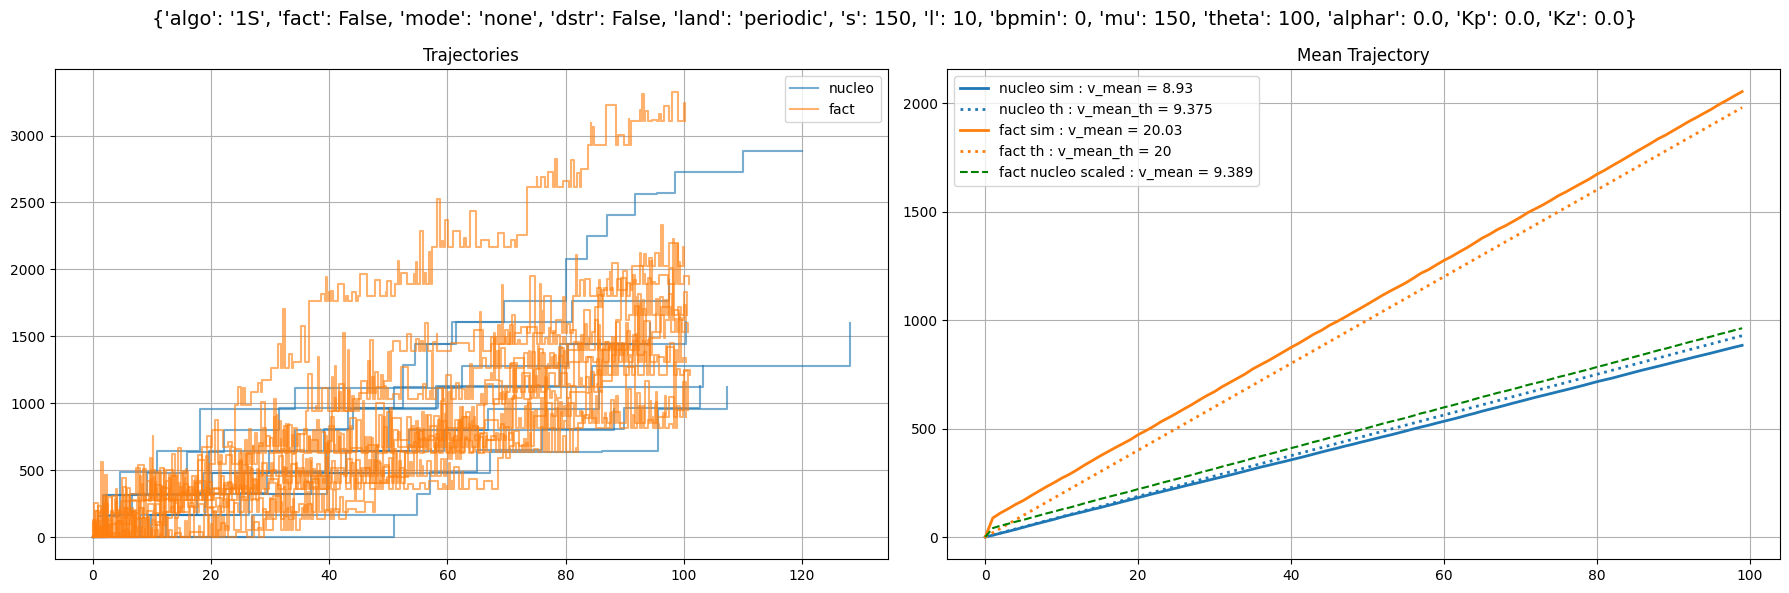

In [8]:
# ── I.2 : DATA COMPARAISON ──────────────────────────────────────────────────────────────────────

# Comparing both approaches
# Getting adpated values
# Checking the validity of the second method


# ── PARAMS ──────────────────────────────────────────────────────────────────────

params_single_nucleo = {
    "algo"      : "1S",
    "fact"      : False,
    "mode"      : "none",
    "dstr"      : False, 
    "land"      : "periodic",
    "s"         : 150,
    "l"         : 10,
    "bpmin"     : 0,
    "mu"        : 150,
    "theta"     : 100,
    "alphar"    : 0.00,
    "Kp"        : 0.00,
    "Kz"        : 0.00
}

params_fact = {
    **params_single_nucleo,
    "algo"      : "2S",
    "fact"      : True,
    "mode"      : "passfull",
    "s"         : 35,
    "l"         : 10,
}


# ── READING ──────────────────────────────────────────────────────────────────────

df_single_nucleo    = finding_one_parquet(root=root_nucleo, params=params_single_nucleo)
df_single_fact      = finding_one_parquet(root=root_fact, params=params_fact)

if df_single_nucleo.columns == df_single_fact.columns:
    print("\n# ──  Ready for study ── #")


# ── PLOT : Function ──────────────────────────────────────────────────────────────────────

def plot_df_main_info(dfs: list[tuple[pl.DataFrame, pl.DataFrame, str]], title: str = "") -> None:
    fig, (ax1, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(18, 6))
    if title:
        fig.suptitle(title, fontsize=14)
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for idx, (df, df_other, label) in enumerate(dfs):
        color = colors[idx % len(colors)]

        # Trajectories
        x1 = df["t_matrix"][0].to_numpy()
        y1 = df["x_matrix"][0].to_numpy()
        for i in range(10):
            ax1.plot(x1[i], y1[i], drawstyle="steps-mid", color=color,
                     alpha=0.6, label=label if i == 0 else None)

        # Data
        times        = df["times"][0].to_numpy()
        results_mean = df["results_mean"][0].to_numpy()
        v_mean       = df["v_mean"][0]
        v_mean_th    = df["v_mean_th"][0]
        y_th         = times * v_mean_th


        # Plot        
        ax2.plot(times, results_mean, color=color,
                 label=f"{label} sim : v_mean = {v_mean:.4g}", ls="-", lw=2)
        ax2.plot(times, y_th, color=color,
                 label=f"{label} th : v_mean_th = {v_mean_th:.4g}", ls=":", lw=2)

        # Scaling
        if "fact" in label:
            alphac   = df["alphac"][0]
            rcapt    = df["rcapt"][0]
            rrest    = df["rrest"][0]
            lF       = df["l"][0]
            sF       = df["s"][0]
            lN       = df_other["l"][0]
            sN       = df_other["s"][0]
            factor   = 1 / (1/rcapt + 1/rrest) * alphac * (lF / (lF + sF)) * ((sN + lN) / lN)
            y_scaled = results_mean / factor
            v_nucleo = v_mean / factor
            ax2.plot(times, y_scaled, color="g",
                     label=f"{label} nucleo scaled : v_mean = {v_nucleo:.4g}", ls="--")

    ax1.set_title("Trajectories")
    ax1.grid(True, which="both")
    ax1.legend()
    ax2.set_title(f"Mean Trajectory")
    ax2.grid(True, which="both")
    ax2.legend()
    plt.tight_layout()
    plt.show()


# ── PLOT : Call ──────────────────────────────────────────────────────────────────────

plot_df_main_info(
    dfs=[
        (df_single_nucleo, df_single_fact, "nucleo"),
        (df_single_fact, df_single_nucleo, "fact"),
    ],
    title=f"{params_single_nucleo}"
)

In [ ]:
# ── I.3 : DATA GAINS ──────────────────────────────────────────────────────────────────────

# 



# ── ADDING GAINS ─────────────────────────────────────────────────────────────

df_all = df_all_fact.clone()

ALL_KEYS = ["algo", "fact", "mode", "dstr", "land", "s", "l", "bpmin", "mu", "theta", "Kp", "Kz"]
FILTERS  = {"Kp": 0, "Kz": 0}
GAINS    = [("v_mean", "Gv"), ("wf", "Gw")]


def add_gain_columns(
    df: pl.DataFrame,
    all_keys: list[str],
    ref_filters: dict[str, object],
    cols_to_normalize: list[tuple[str, str]],
    cross_dims: list[str] | None = None,
) -> pl.DataFrame:
    """
    Calcule des gains normalisés par rapport à une ligne de référence.

    Paramètres
    ----------
    all_keys          : colonnes identifiant un scénario unique.
    ref_filters       : conditions définissant la référence (ex: {"Kp": 0, "land": "homogen"}).
    cols_to_normalize : liste de (colonne_source, nom_du_gain).
    cross_dims        : dimensions exclues du join (référence partagée entre scénarios).
                        Par défaut : les clés de ref_filters.
    """
    
    if cross_dims is None:
        cross_dims = list(ref_filters.keys())

    join_keys = [k for k in all_keys if k not in cross_dims]

    # Référence : moyenne des colonnes cibles sur les lignes filtrées
    ref_mask = pl.all_horizontal(pl.col(col) == val for col, val in ref_filters.items())
    df_ref = (
        df.filter(ref_mask)
        .group_by(join_keys)
        .agg(pl.col(src).mean().alias(f"_ref_{alias}") for src, alias in cols_to_normalize)
    )

    # Join et normalisation
    ref_cols = [f"_ref_{alias}" for _, alias in cols_to_normalize]
    return (
        df.join(df_ref, on=join_keys, how="left")
        .with_columns((pl.col(src) / pl.col(f"_ref_{alias}")).alias(alias) for src, alias in cols_to_normalize)
        .drop(ref_cols)
    )

# Cas 1 : référence Kp==0 & land==homogen, partagée entre tous les scénarios
df_cross = add_gain_columns(
    df_all,
    all_keys          = ALL_KEYS,
    ref_filters       ={
        **FILTERS,
        "land": "homogen",
    },
    cols_to_normalize = GAINS,
    cross_dims        = ["land"],   # seulement land à exclure du join
)

# Cas 2 : référence Kp==0, chaque land garde sa propre référence
df_per = add_gain_columns(
    df_all,
    all_keys          = ALL_KEYS,
    ref_filters       = FILTERS,
    cols_to_normalize = GAINS,
    # cross_dims = [] par défaut → join sur les 11 clés exactement
)


# ── CHECKING ──────────────────────────────────────────────────────────────────
df_check = (
    df_per
    .filter(
        (pl.col("s")     == 35  ) &
        (pl.col("mu")    == 150 ) &
        (pl.col("theta") == 100 ) &
        (pl.col("Kz")    == 0.00) &
        (pl.col("Kp")    == 0.00)
    )
    .select(["land", "mode", "l", "Gv", "Gw"])
)
print(df_check)


# ── CHOOSING ──────────────────────────────────────────────────────────────────

df_study = df_per
